Estaciones troncales cargadas: 153
Grafo de Transmilenio creado -> Nodos (V): 152, Aristas (E): 136


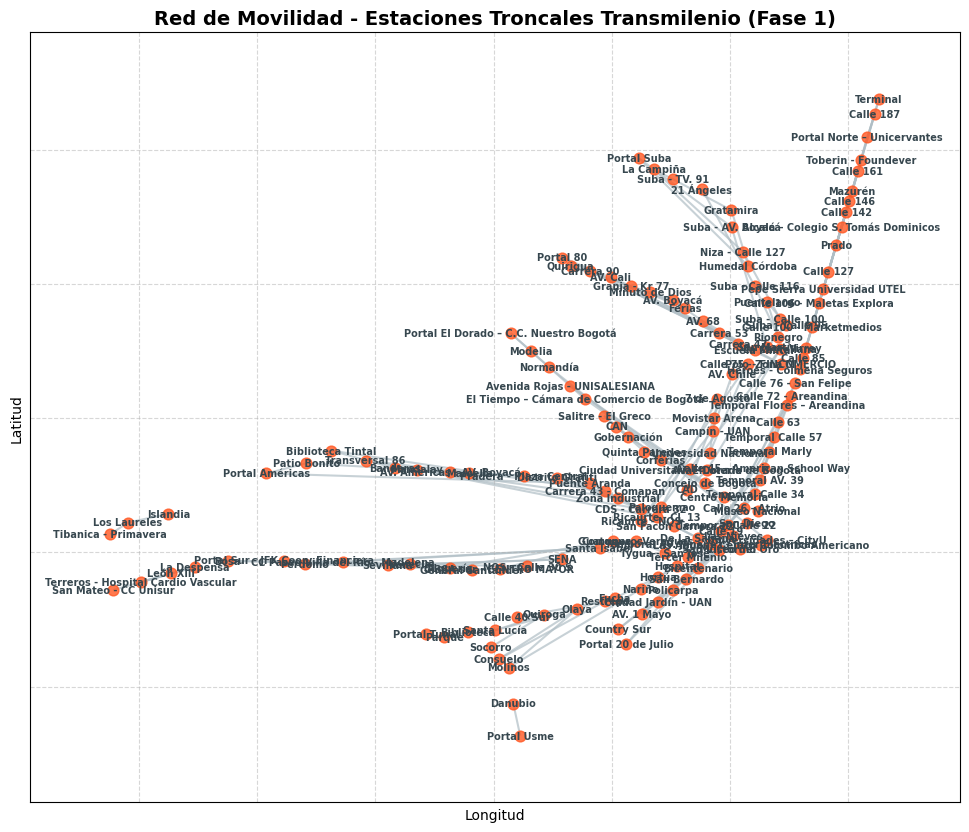

¡Imagen guardada como 'red_transmilenio_fase1.png' lista para tu informe!


In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# 1. Cargar el dataset original de estaciones troncales
df = pd.read_csv('Estacion_troncalT.csv')
print(f"Estaciones troncales cargadas: {len(df)}")

# 2. Construir el Grafo G = (V, E)
G = nx.Graph()

# Agregar nodos (Estaciones)
for idx, row in df.iterrows():
    G.add_node(
        row['nom_est'],
        pos=(row['longitud'], row['latitud']),
        codigo=row['num_est'],
        trazado=row['id_trazado'],
        capacidad=row['cap_art']
    )

# Agregar aristas basadas en la continuidad de cada trazado (id_trazado)
for trazado, group in df.groupby('id_trazado'):
    stations = group['nom_est'].tolist()
    for i in range(len(stations) - 1):
        s1 = stations[i]
        s2 = stations[i+1]

        # Calcular distancia aproximada en km a partir de coordenadas
        lat1, lon1 = df[df['nom_est']==s1][['latitud', 'longitud']].values[0]
        lat2, lon2 = df[df['nom_est']==s2][['latitud', 'longitud']].values[0]
        dist_km = np.sqrt((lat2 - lat1)**2 + (lon2 - lon1)**2) * 111.0

        G.add_edge(s1, s2, weight=dist_km, distancia=dist_km)

print(f"Grafo de Transmilenio creado -> Nodos (V): {G.number_of_nodes()}, Aristas (E): {G.number_of_edges()}")

# 3. Generar visualización limpia y estética para el informe del Corte 1
plt.figure(figsize=(12, 10))
pos = nx.get_node_attributes(G, 'pos')

# Dibujar nodos y aristas
nx.draw_networkx_nodes(G, pos, node_size=60, node_color='#ff5722', alpha=0.8)
nx.draw_networkx_edges(G, pos, width=1.5, edge_color='#b0bec5', alpha=0.7)

# Etiquetas para algunas estaciones clave o muestra (para no saturar el gráfico)
# Si quieres ver todas las etiquetas puedes quitar el filtro, pero con 150 estaciones se ve mejor limpio o con un subconjunto
nx.draw_networkx_labels(G, pos, font_size=7, font_weight='bold', font_color='#37474f')

plt.title("Red de Movilidad - Estaciones Troncales Transmilenio (Fase 1)", fontsize=14, fontweight='bold')
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.grid(True, linestyle='--', alpha=0.5)

# Guardar imagen para el documento
plt.savefig("red_transmilenio_fase1.png", dpi=300, bbox_inches='tight')
plt.show()

print("¡Imagen guardada como 'red_transmilenio_fase1.png' lista para tu informe!")